# Data Visualization 1: Distributions

> "The simple graph has brought more information to the data analyst's mind than any other device." — John Tukey

In this lesson we use **seaborn** (built on top of **matplotlib**) to explore a single dataset of penguins. We will:

- build up a scatterplot one question at a time, and
- learn how to visualize the *distribution* of a single variable.

The guiding idea throughout is that **every plot answers a question**. We will keep our attention on the questions and on reading the answers off the chart, rather than on fine-grained styling.

## Setup

In [1]:
# pandas for tabular data: https://pandas.pydata.org/docs/
import pandas as pd

# matplotlib is the underlying plotting engine: https://matplotlib.org/stable/
import matplotlib.pyplot as plt

# seaborn is a high-level statistical plotting library: https://seaborn.pydata.org/
import seaborn as sns

# Apply seaborn's default theme (colors, fonts, grid) to every matplotlib figure.
sns.set_theme()

## The `penguins` dataset

seaborn ships with a few example datasets. `load_dataset("penguins")` returns the **Palmer Penguins** data as a pandas `DataFrame`: body measurements for penguins on three islands in the Palmer Archipelago.

It contains the same key columns as the original `palmerpenguins` data:

- `species` — the penguin's species (Adelie, Chinstrap, or Gentoo)
- `island` — the island where the penguin was observed
- `bill_length_mm`, `bill_depth_mm` — bill measurements, in millimeters
- `flipper_length_mm` — flipper length, in millimeters
- `body_mass_g` — body mass, in grams
- `sex` — the penguin's sex

A `DataFrame` is a rectangular table: **variables** live in columns and **observations** (here, individual penguins) live in rows.

In [2]:
# load_dataset downloads (and caches) a tidy example DataFrame.
penguins = sns.load_dataset("penguins")

# head() previews the first 5 rows so we can eyeball the columns and values.
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


`info()` is a quick way to see every column, its data type, and how many non-missing values it has. Notice that a few measurement columns have fewer than the total number of rows — those are **missing values**, which seaborn quietly drops when plotting.

In [3]:
# info() reports column names, dtypes, and non-null counts in one summary.
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## First steps: building a scatterplot

Let's start with a concrete question:

> Do penguins with longer flippers weigh more or less than penguins with shorter flippers?

Try to make your answer precise. Is the relationship positive or negative? Linear or curved? Strong or weak? Does it depend on the species? A **scatterplot** of two numerical variables is the natural tool to find out.

We map `flipper_length_mm` to the x-axis and `body_mass_g` to the y-axis.

Text(0.5, 1.0, 'Body mass vs. flipper length')

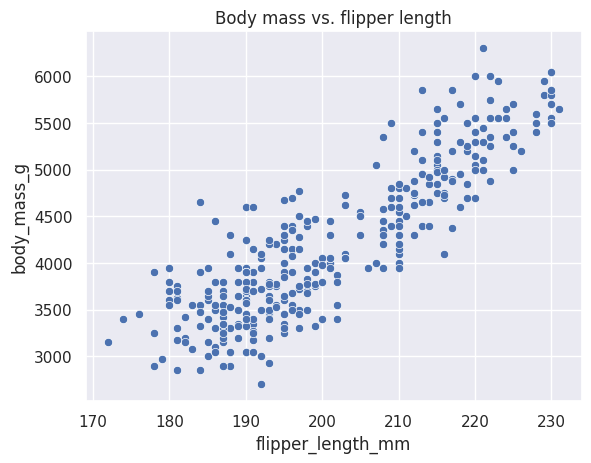

In [4]:
# Create an explicit Figure and Axes (the object-oriented matplotlib API).
fig, ax = plt.subplots()

# scatterplot draws one point per penguin. data= is the DataFrame; x/y are column names.
sns.scatterplot(
    data=penguins,           # the DataFrame to read columns from
    x="flipper_length_mm",   # horizontal position of each point
    y="body_mass_g",         # vertical position of each point
    ax=ax,                   # draw onto the Axes we created
)

ax.set_title("Body mass vs. flipper length")

Already we can answer the motivating question: the relationship looks **positive** (longer flippers go with heavier penguins), **fairly linear** (points cluster around a straight line), and **moderately strong** (not too much scatter).

It is always wise to be skeptical and ask whether a *third* variable changes the story. Does the relationship differ by species? We can encode species with color by mapping it to the `hue` aesthetic. seaborn assigns one color per species automatically and adds a legend.

Text(0.5, 1.0, 'Body mass vs. flipper length, by species')

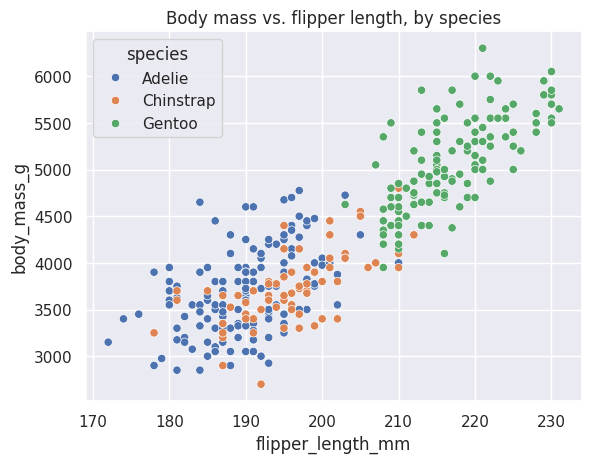

In [5]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # color each point by its species, and add a legend
    ax=ax,
)

ax.set_title("Body mass vs. flipper length, by species")

### Adding a line of best fit

To make the trend explicit we can overlay a **regression line** (a straight line fit through the points). `regplot` draws the scatter *and* a best-fit line with a shaded confidence band on the same Axes.

Text(0.5, 1.0, 'Body mass vs. flipper length with a line of best fit')

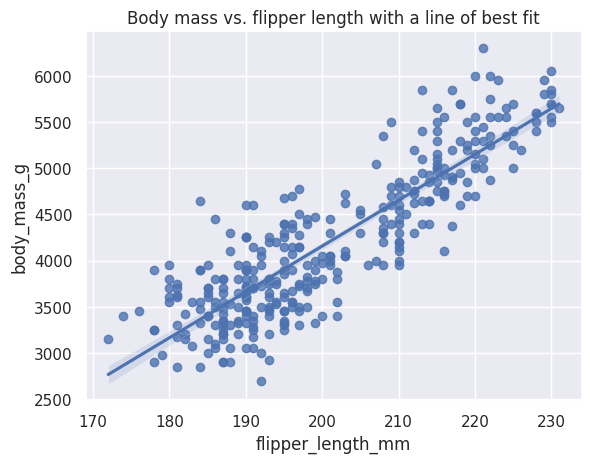

In [6]:
fig, ax = plt.subplots()

# regplot = scatter points + a fitted straight line (ordinary least squares).
sns.regplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass vs. flipper length with a line of best fit")

The upward-sloping line confirms the positive relationship we saw by eye. The points hug the line reasonably closely, which is the visual signature of a *strong* linear relationship.

## Visualizing the distribution of one variable

How we picture the distribution of a *single* variable depends on whether it is **categorical** or **numerical**.

### A categorical variable

A variable is **categorical** when it takes one of a small set of values, like `species`. A **count plot** (bar chart) shows how many observations fall into each category.

Text(0.5, 1.0, 'Number of penguins per species')

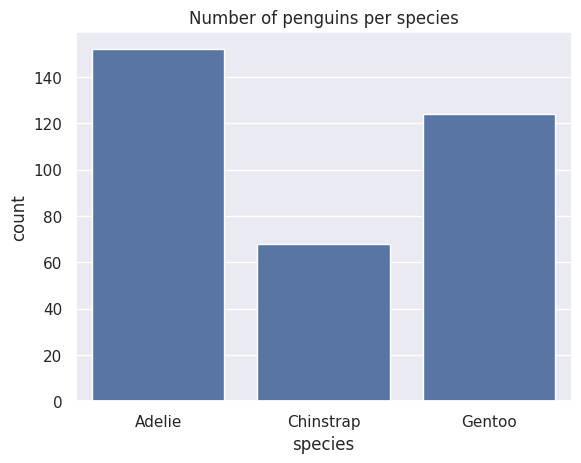

In [7]:
fig, ax = plt.subplots()

# countplot tallies the rows in each category and draws one bar per category.
sns.countplot(
    data=penguins,
    x="species",
    ax=ax,
)

ax.set_title("Number of penguins per species")

For categories with no natural order, it is often easier to read the chart when the bars are **sorted by frequency**. We compute the order with `value_counts()` (which is already sorted from most to least common) and pass its index to the `order` argument.

Text(0.5, 1.0, 'Penguins per species, ordered by frequency')

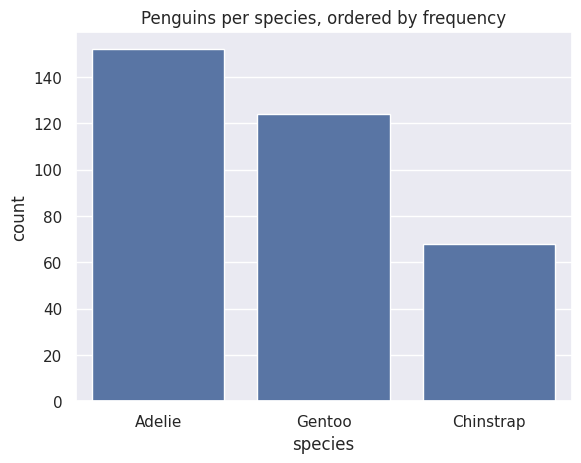

In [8]:
# value_counts() returns counts sorted high-to-low; its index is the species order.
species_by_frequency = penguins["species"].value_counts().index

fig, ax = plt.subplots()

sns.countplot(
    data=penguins,
    x="species",
    order=species_by_frequency,   # draw bars from most to least common
    ax=ax,
)

ax.set_title("Penguins per species, ordered by frequency")

### A numerical variable

A variable is **numerical** when it spans a range of numbers it makes sense to add or average, like `body_mass_g`.

A **histogram** splits the range into equal-width bins and draws a bar whose height is the number of observations in each bin.

Text(0.5, 1.0, 'Distribution of body mass')

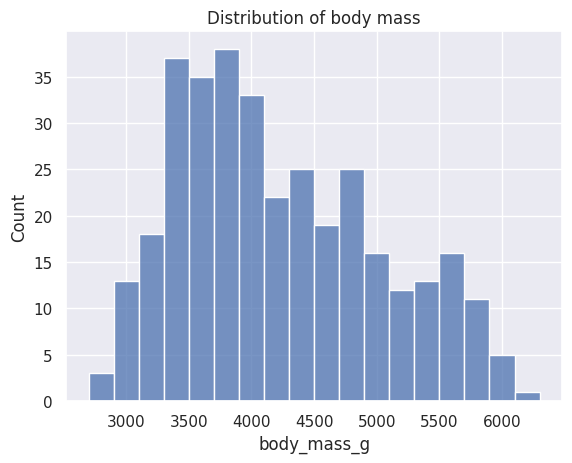

In [9]:
fig, ax = plt.subplots()

# histplot bins a numerical column; binwidth sets the width of each bin (in grams here).
sns.histplot(
    data=penguins,
    x="body_mass_g",
    binwidth=200,   # try other values: too small looks jagged, too large hides the shape
    ax=ax,
)

ax.set_title("Distribution of body mass")

Always try a few bin widths: too narrow makes a jagged chart, too wide hides the shape. A width of 200 g strikes a sensible balance and shows a single peak (unimodal) that trails off to the right (slightly right-skewed).

A **density (KDE) plot** is a smoothed alternative to the histogram. It is useful for continuous data and makes the overall shape — peaks and skew — easy to read at a glance.

Text(0.5, 1.0, 'Smoothed density of body mass')

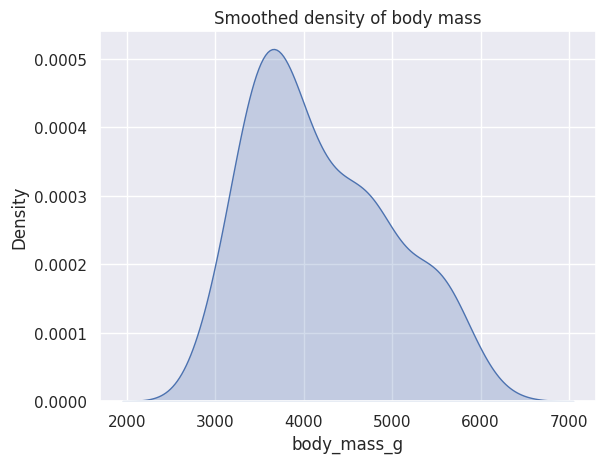

In [10]:
fig, ax = plt.subplots()

# kdeplot draws a smooth density curve; fill shades the area under it.
sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    fill=True,
    ax=ax,
)

ax.set_title("Smoothed density of body mass")

## Summary

- A **scatterplot** (`sns.scatterplot`) shows the relationship between two numerical variables; mapping a third variable to `hue` reveals whether groups behave differently.
- `sns.regplot` adds a **line of best fit** to make a trend explicit.
- For a single **categorical** variable, a **count plot** (`sns.countplot`) shows how many observations fall in each category; sort by frequency for easier reading.
- For a single **numerical** variable, a **histogram** (`sns.histplot`) and a **density plot** (`sns.kdeplot`) both reveal the shape of the distribution.

Next, in `02_relationships.ipynb`, we move from one variable to relationships *between* two variables.